# MLP Back-Programation

In [98]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import tensorflow as tf
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import Callback, EarlyStopping
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold


## 1. Avaliando Pesos Iniciais e Funções de ativação

In [22]:
# load do dataset
df = pd.read_excel("Dry_Bean_Dataset.xlsx")
x =  df.drop("Class", axis=1)
y = df["Class"]

tabela_classes = (
    df["Class"]
    .value_counts()
    .reset_index()
)

tabela_classes.columns = ["Classe", "Quantidade"]

print(tabela_classes)

# Categoria -> numero

encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Divisão do dataser

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  

#Nomalização

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


     Classe  Quantidade
0  DERMASON        3546
1      SIRA        2636
2     SEKER        2027
3     HOROZ        1928
4      CALI        1630
5  BARBUNYA        1322
6    BOMBAY         522


In [12]:
#Rede Neural

def mlp():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(16,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(7, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [21]:
#Treinamento com pesos diferentes
seeds = [1, 2, 3, 4, 5]

historicos = []

for seed in seeds:

    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    model = mlp()

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        verbose=0
    )

    loss_final = history.history['loss'][-1]
    acc_final = history.history['accuracy'][-1]

    historicos.append(history.history)

resultados = []

for i, h in enumerate(historicos):

    resultados.append({
        'Seed': seeds[i],
        'Loss Final': h['loss'][-1],
        'Accuracy Final': h['accuracy'][-1]
    })

df_resultados = pd.DataFrame(resultados)

print(df_resultados)

   Seed  Loss Final  Accuracy Final
0     1    0.163097        0.937821
1     2    0.161734        0.938648
2     3    0.162260        0.936719
3     4    0.160708        0.937913
4     5    0.166993        0.938464


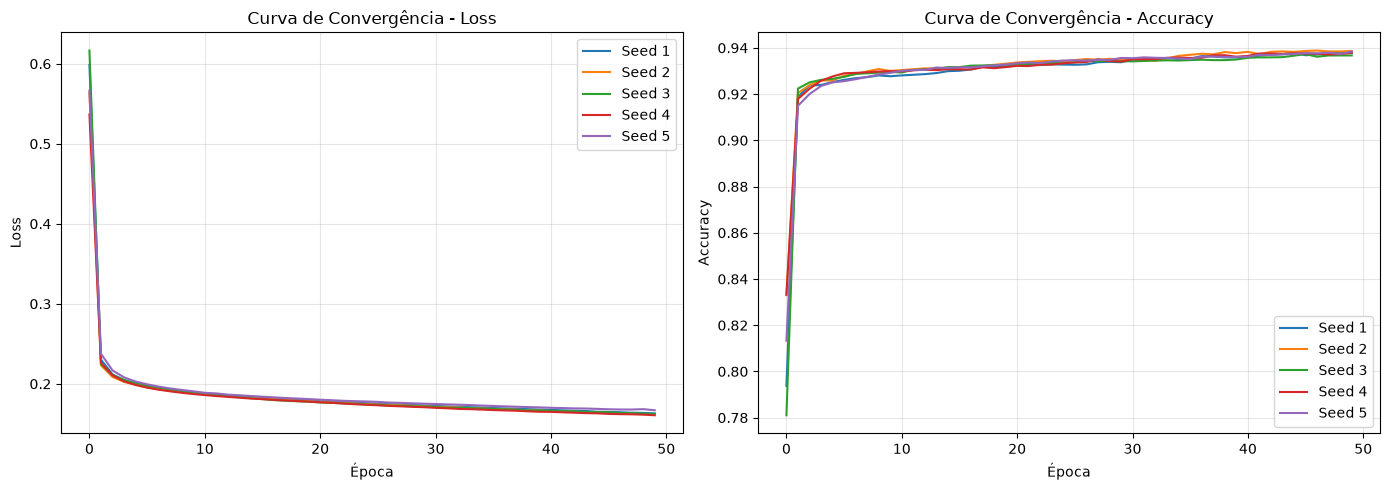

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for i, h in enumerate(historicos):
    ax1.plot(
        h['loss'],
        label=f'Seed {seeds[i]}'
    )

ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.set_title('Curva de Convergência - Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
for i, h in enumerate(historicos):
    ax2.plot(
        h['accuracy'],
        label=f'Seed {seeds[i]}'
    )

ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.set_title('Curva de Convergência - Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.Taxa de Aprendizado e Termo Momento

In [25]:
class StopByLoss(Callback):

    def on_epoch_end(self, epoch, logs=None):

        if logs["loss"] <= 0.001:
            print(f"\nParando treinamento: loss = {logs['loss']:.6f}")
            self.model.stop_training = True

In [ ]:
def mlp_sgd(lr, momentum):

    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(7, activation='softmax')
    ])

    optimizer = SGD(
        learning_rate=lr,
        momentum=momentum
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [31]:
learning_rates = [0.001, 0.01, 0.1]
momenta = [0.5, 0.7, 0.9]

resultados = []
historicos = {}

for lr in learning_rates:

    for momentum in momenta:

        print(
            f"\nTreinando:"
            f" LR={lr}"
            f" Momentum={momentum}"
        )

        model = mlp_sgd(lr, momentum)

        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=32,
            verbose=1,
            callbacks=[StopByLoss()]
        )

        historicos[(lr, momentum)] = history.history

        resultados.append({
            "Learning Rate": lr,
            "Momentum": momentum,
            "Loss Final": history.history["loss"][-1],
            "Accuracy Final": history.history["accuracy"][-1],
            "Épocas": len(history.history["loss"])
        })


Treinando: LR=0.001 Momentum=0.5
Epoch 1/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5365 - loss: 1.5365
Epoch 2/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6635 - loss: 1.1604
Epoch 3/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7142 - loss: 0.9482
Epoch 4/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7528 - loss: 0.8095
Epoch 5/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7908 - loss: 0.7044
Epoch 6/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - accuracy: 0.8282 - loss: 0.6212
Epoch 7/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8571 - loss: 0.5553
Epoch 8/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8749 - loss: 0.5033
Epoch 9/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8849 - loss: 0.4623
Epoch 10/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8921 - loss: 0.4297
Epoch 11/50
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8964 - loss: 0.4033
Epoch 12/50
341/

In [32]:
df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by="Épocas"
)

print("\nRESULTADOS:")
print(df_resultados)


RESULTADOS:
   Learning Rate  Momentum  Loss Final  Accuracy Final  Épocas
0          0.001       0.5    0.220064        0.923126      50
1          0.001       0.7    0.204364        0.926708      50
2          0.001       0.9    0.185401        0.930566      50
3          0.010       0.5    0.178795        0.932403      50
4          0.010       0.7    0.176384        0.933229      50
5          0.010       0.9    0.171244        0.937087      50
6          0.100       0.5    0.164858        0.935434      50
7          0.100       0.7    0.161329        0.937546      50
8          0.100       0.9    0.202583        0.927810      50


In [33]:
melhor = df_resultados.loc[
    df_resultados["Épocas"].idxmin()
]

print("\nMELHOR CONFIGURAÇÃO:")
print(melhor)


MELHOR CONFIGURAÇÃO:
Learning Rate      0.001000
Momentum           0.500000
Loss Final         0.220064
Accuracy Final     0.923126
Épocas            50.000000
Name: 0, dtype: float64


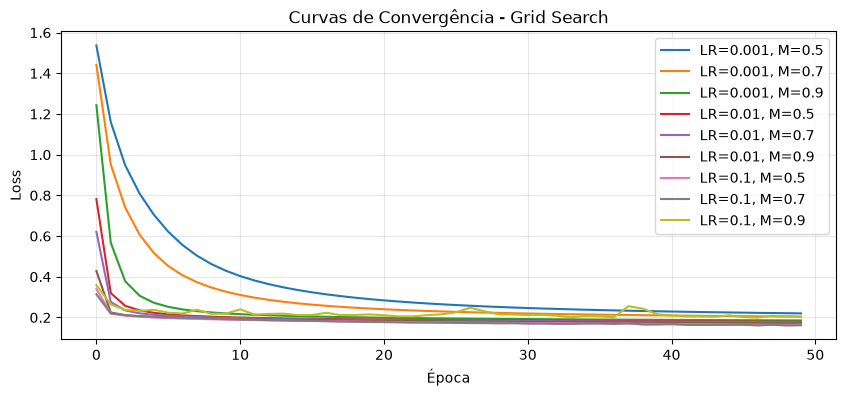

In [36]:
plt.figure(figsize=(10, 4))

for chave, hist in historicos.items():

    lr, momentum = chave

    plt.plot(
        hist["loss"],
        label=f"LR={lr}, M={momentum}"
    )

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curvas de Convergência - Grid Search")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [35]:
df_resultados["Loss Final"] = df_resultados["Loss Final"].round(4)
df_resultados["Accuracy Final"] = (
    df_resultados["Accuracy Final"] * 100
).round(2)

print("\nTABELA FINAL:")
print(df_resultados)


TABELA FINAL:
   Learning Rate  Momentum  Loss Final  Accuracy Final  Épocas
0          0.001       0.5      0.2201           92.31      50
1          0.001       0.7      0.2044           92.67      50
2          0.001       0.9      0.1854           93.06      50
3          0.010       0.5      0.1788           93.24      50
4          0.010       0.7      0.1764           93.32      50
5          0.010       0.9      0.1712           93.71      50
6          0.100       0.5      0.1649           93.54      50
7          0.100       0.7      0.1613           93.75      50
8          0.100       0.9      0.2026           92.78      50


## 3.Topologia da Rede – Influência do Número de Camadas e Neurônios por Camada

In [38]:
def mlp(num_camadas, num_neuronios):

    model = Sequential()

    model.add(
        Input(shape=(X_train.shape[1],))
    )

    for _ in range(num_camadas):

        model.add(
            Dense(
                num_neuronios,
                activation='relu'
            )
        )

    model.add(
        Dense(
            7,
            activation='softmax'
        )
    )

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [42]:
camadas = [1, 2, 3]

neuronios = [
    10, 20, 30, 40, 50,
    60, 70, 80, 90, 100
]
resultados = []

historicos = {}

for n_camadas in camadas:

    for n_neuronios in neuronios:

        print(
            f"Camadas={n_camadas}"
            f" | Neurônios={n_neuronios}"
        )

        model = mlp(
            n_camadas,
            n_neuronios
        )

        inicio = time.time()

        history = model.fit(
            X_train,
            y_train,
            validation_data=(
                X_test,
                y_test
            ),
            epochs=50,
            batch_size=32,
            verbose=0
        )

        tempo = time.time() - inicio

        historicos[
            (n_camadas, n_neuronios)
        ] = history.history

        resultados.append({
            "Camadas": n_camadas,
            "Neuronios": n_neuronios,

            "Loss Treino":
                history.history["loss"][-1],

            "Loss Val":
                history.history["val_loss"][-1],

            "Accuracy Treino":
                history.history["accuracy"][-1],

            "Accuracy Val":
                history.history["val_accuracy"][-1],

            "Tempo":
                tempo
        })

Camadas=1 | Neurônios=10
Camadas=1 | Neurônios=20
Camadas=1 | Neurônios=30
Camadas=1 | Neurônios=40
Camadas=1 | Neurônios=50
Camadas=1 | Neurônios=60
Camadas=1 | Neurônios=70
Camadas=1 | Neurônios=80
Camadas=1 | Neurônios=90
Camadas=1 | Neurônios=100
Camadas=2 | Neurônios=10
Camadas=2 | Neurônios=20
Camadas=2 | Neurônios=30
Camadas=2 | Neurônios=40
Camadas=2 | Neurônios=50
Camadas=2 | Neurônios=60
Camadas=2 | Neurônios=70
Camadas=2 | Neurônios=80
Camadas=2 | Neurônios=90
Camadas=2 | Neurônios=100
Camadas=3 | Neurônios=10
Camadas=3 | Neurônios=20
Camadas=3 | Neurônios=30
Camadas=3 | Neurônios=40
Camadas=3 | Neurônios=50
Camadas=3 | Neurônios=60
Camadas=3 | Neurônios=70
Camadas=3 | Neurônios=80
Camadas=3 | Neurônios=90
Camadas=3 | Neurônios=100


In [43]:
df_topologias = pd.DataFrame(resultados)

df_topologias = df_topologias.round(4)

print(df_topologias)

top10 = (
    df_topologias
    .sort_values(
        by="Accuracy Val",
        ascending=False
    )
)

print(top10.head(10))

melhor = top10.iloc[0]

print(melhor)

    Camadas  Neuronios  Loss Treino  Loss Val  Accuracy Treino  Accuracy Val  \
0         1         10       0.1964    0.2030           0.9263        0.9295   
1         1         20       0.1859    0.1928           0.9300        0.9328   
2         1         30       0.1803    0.1907           0.9307        0.9321   
3         1         40       0.1770    0.1855           0.9330        0.9350   
4         1         50       0.1761    0.1882           0.9342        0.9343   
5         1         60       0.1726    0.1900           0.9352        0.9335   
6         1         70       0.1715    0.1879           0.9353        0.9310   
7         1         80       0.1716    0.1843           0.9351        0.9317   
8         1         90       0.1698    0.1870           0.9359        0.9332   
9         1        100       0.1724    0.1866           0.9347        0.9328   
10        2         10       0.1894    0.1924           0.9289        0.9339   
11        2         20       0.1815    0

In [ ]:

df_topologias["Gap"] = abs(
    df_topologias["Accuracy Treino"]
    - df_topologias["Accuracy Val"]
)

melhores_redes = (
    df_topologias
    .sort_values(
        by=[
            "Accuracy Val",
            "Gap",
            "Loss Val"
        ],
        ascending=[
            False,
            True,
            True
        ]
    )
    .head(4)
    .reset_index(drop=True)
)

print("\n=== TOP 4 REDES ===\n")
print(melhores_redes)


=== TOP 4 REDES ===

   Camadas  Neuronios  Loss Treino  Loss Val  Accuracy Treino  Accuracy Val  \
0        1         40       0.1770    0.1855           0.9330        0.9350   
1        1         50       0.1761    0.1882           0.9342        0.9343   
2        2         10       0.1894    0.1924           0.9289        0.9339   
3        1         60       0.1726    0.1900           0.9352        0.9335   

     Tempo     Gap  
0  24.3079  0.0020  
1  23.3006  0.0001  
2  27.3357  0.0050  
3  24.4637  0.0017  


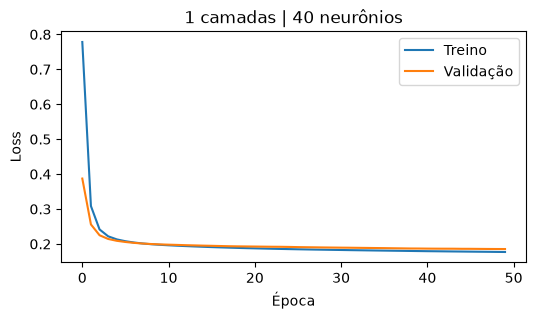

In [45]:
melhor_camadas = int(melhor["Camadas"])
melhor_neuronios = int(melhor["Neuronios"])

hist = historicos[
    (
        melhor_camadas,
        melhor_neuronios
    )
]
plt.figure(figsize=(6,3))

plt.plot(
    hist["loss"],
    label="Treino"
)

plt.plot(
    hist["val_loss"],
    label="Validação"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.title(
    f"{melhor_camadas} camadas "
    f"| {melhor_neuronios} neurônios"
)

plt.legend()

plt.show()

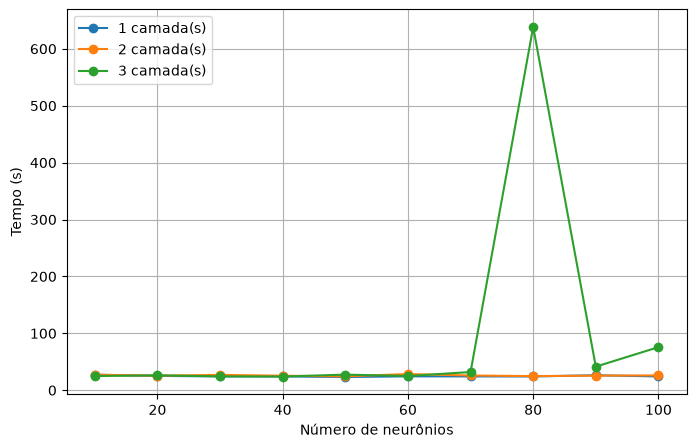

In [57]:
plt.figure(figsize=(8,5))

for c in [1,2,3]:

    subset = df_topologias[
        df_topologias["Camadas"] == c
    ]

    plt.plot(
        subset["Neuronios"],
        subset["Tempo"],
        marker="o",
        label=f"{c} camada(s)"
    )

plt.xlabel("Número de neurônios")
plt.ylabel("Tempo (s)")
plt.legend()
plt.grid(True)

plt.show()

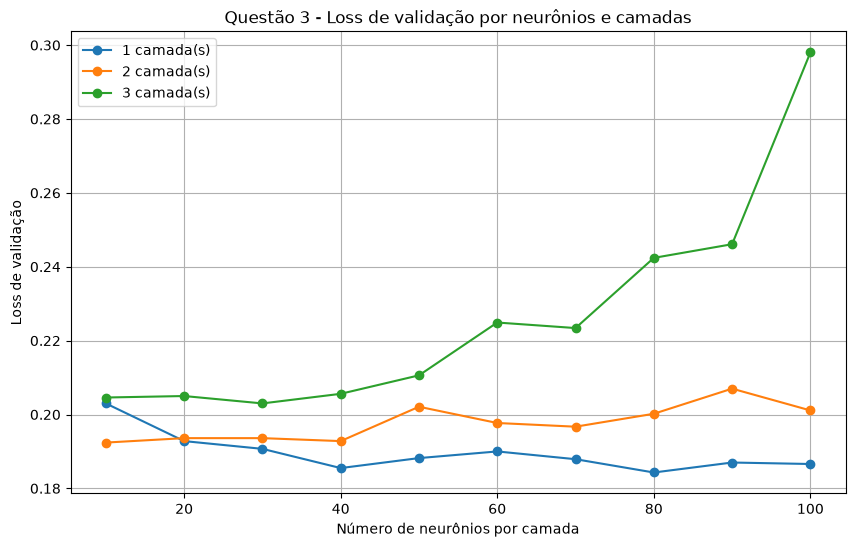

In [113]:
plt.figure(figsize=(10,6))

for camada in sorted(df_topologias["Camadas"].unique()):

    dados = df_topologias[
        df_topologias["Camadas"] == camada
    ]

    plt.plot(
        dados["Neuronios"],
        dados["Loss Val"],
        marker='o',
        label=f"{camada} camada(s)"
    )

plt.title(
    "Questão 3 - Loss de validação por neurônios e camadas"
)

plt.xlabel(
    "Número de neurônios por camada"
)

plt.ylabel(
    "Loss de validação"
)

plt.grid(True)

plt.legend()

plt.show()

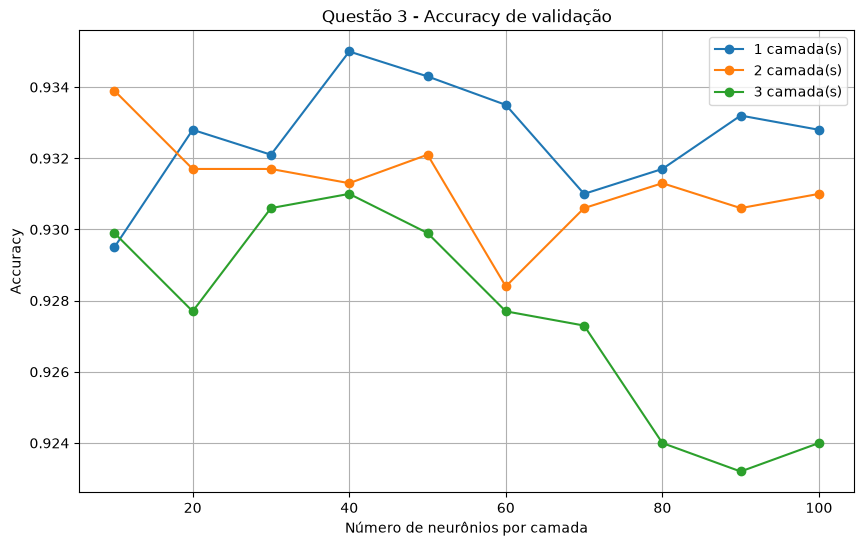

In [112]:
plt.figure(figsize=(10,6))

for camada in sorted(df_topologias["Camadas"].unique()):

    dados = df_topologias[
        df_topologias["Camadas"] == camada
    ]

    plt.plot(
        dados["Neuronios"],
        dados["Accuracy Val"],
        marker='o',
        label=f"{camada} camada(s)"
    )

plt.title(
    "Questão 3 - Accuracy de validação"
)

plt.xlabel(
    "Número de neurônios por camada"
)

plt.ylabel(
    "Accuracy"
)

plt.grid(True)

plt.legend()

plt.show()

In [47]:
model_final = mlp(
    melhor_camadas,
    melhor_neuronios
)

model_final.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    verbose=0
)
y_pred_prob = model_final.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [48]:
precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.9334908357760332
Recall: 0.9327947117150202
F1: 0.9330430260665786


## 4.Influência dos Dados de Treinamento – Qualidade e Quantidade de Exemplos

In [50]:
def melhor_rede():

    model = Sequential([
        Input(shape=(16,)), 
        Dense(40,activation='relu'),
        Dense(7,activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [51]:

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

fracoes = [0.2,0.4,0.6,0.8,1.0]

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=50,
    verbose=0
)

In [52]:
resultados = []

for frac in fracoes:

    print(
        f"\nTreinando com {int(frac*100)}% dos dados"
    )
    if frac < 1.0:

        X_sub, _, y_sub, _ = train_test_split(
            X_train_final,
            y_train_final,
            train_size=frac,
            random_state=42,
            stratify=y_train_final
        )

    else:

        X_sub = X_train_final
        y_sub = y_train_final

    model = melhor_rede()
    inicio = time.time()
    history = model.fit(
        X_sub,
        y_sub,
        validation_data=(
            X_val,
            y_val
        ),
        epochs=50,
        batch_size=32,
        verbose=0
    )

    tempo = time.time() - inicio
    y_val_pred = np.argmax(
        model.predict(
            X_val,
            verbose=0
        ),
        axis=1
    )
    y_test_pred = np.argmax(
        model.predict(
            X_test,
            verbose=0
        ),
        axis=1
    )

    acc_val = accuracy_score(
        y_val,
        y_val_pred
    )

    f1_val = f1_score(
        y_val,
        y_val_pred,
        average='weighted'
    )

    acc_test = accuracy_score(
        y_test,
        y_test_pred
    )

    f1_test = f1_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    resultados.append({

        "Dados (%)":
            int(frac * 100),

        "Loss Treino":
            history.history["loss"][-1],

        "Loss Validação":
            history.history["val_loss"][-1],

        "Accuracy Validação":
            acc_val,

        "Accuracy Teste":
            acc_test,

        "F1 Validação":
            f1_val,

        "F1 Teste":
            f1_test,

        "Tempo (s)":
            tempo
    })


Treinando com 20% dos dados

Treinando com 40% dos dados

Treinando com 60% dos dados

Treinando com 80% dos dados

Treinando com 100% dos dados


In [54]:
df_q4 = pd.DataFrame(resultados)

df_q4 = df_q4.round(4)

print("\nRESULTADOS\n")

print(df_q4)


RESULTADOS

   Dados (%)  Loss Treino  Loss Validação  Accuracy Validação  Accuracy Teste  \
0         20       0.1852          0.2185              0.9137          0.9258   
1         40       0.1786          0.2062              0.9219          0.9280   
2         60       0.1766          0.2033              0.9201          0.9266   
3         80       0.1734          0.1931              0.9247          0.9310   
4        100       0.1751          0.1914              0.9279          0.9328   

   F1 Validação  F1 Teste  Tempo (s)  
0        0.9137    0.9260    12.5115  
1        0.9220    0.9283    16.9481  
2        0.9205    0.9269    44.5526  
3        0.9247    0.9312    46.8980  
4        0.9281    0.9330    35.5019  


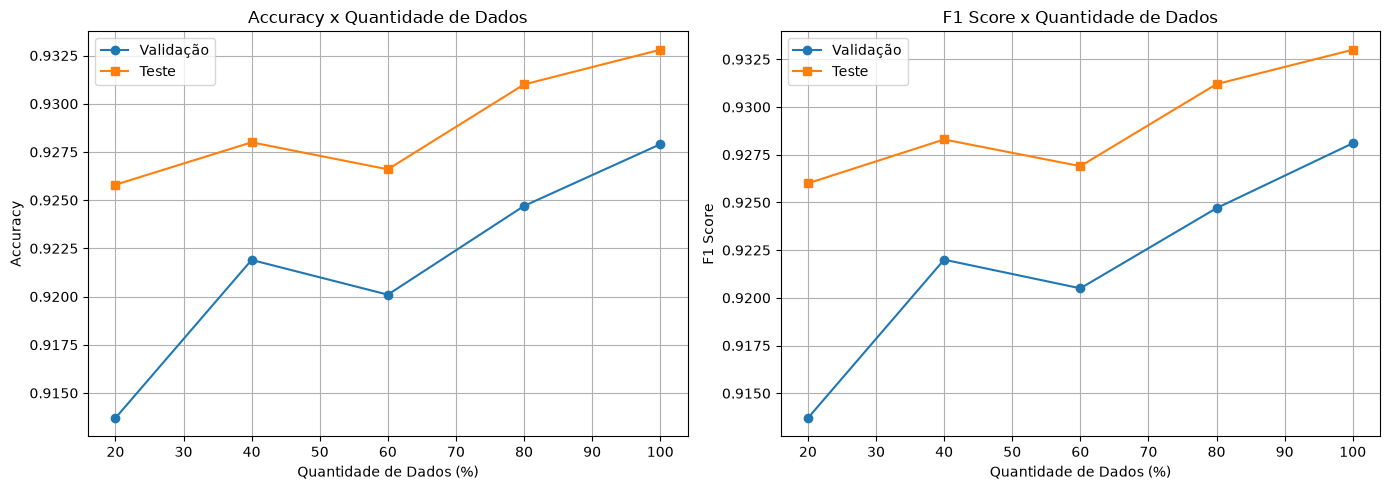

In [55]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14,5)
)

ax1.plot(
    df_q4["Dados (%)"],
    df_q4["Accuracy Validação"],
    marker='o',
    label='Validação'
)

ax1.plot(
    df_q4["Dados (%)"],
    df_q4["Accuracy Teste"],
    marker='s',
    label='Teste'
)

ax1.set_xlabel("Quantidade de Dados (%)")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy x Quantidade de Dados")
ax1.grid(True)
ax1.legend()

ax2.plot(
    df_q4["Dados (%)"],
    df_q4["F1 Validação"],
    marker='o',
    label='Validação'
)

ax2.plot(
    df_q4["Dados (%)"],
    df_q4["F1 Teste"],
    marker='s',
    label='Teste'
)

ax2.set_xlabel("Quantidade de Dados (%)")
ax2.set_ylabel("F1 Score")
ax2.set_title("F1 Score x Quantidade de Dados")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

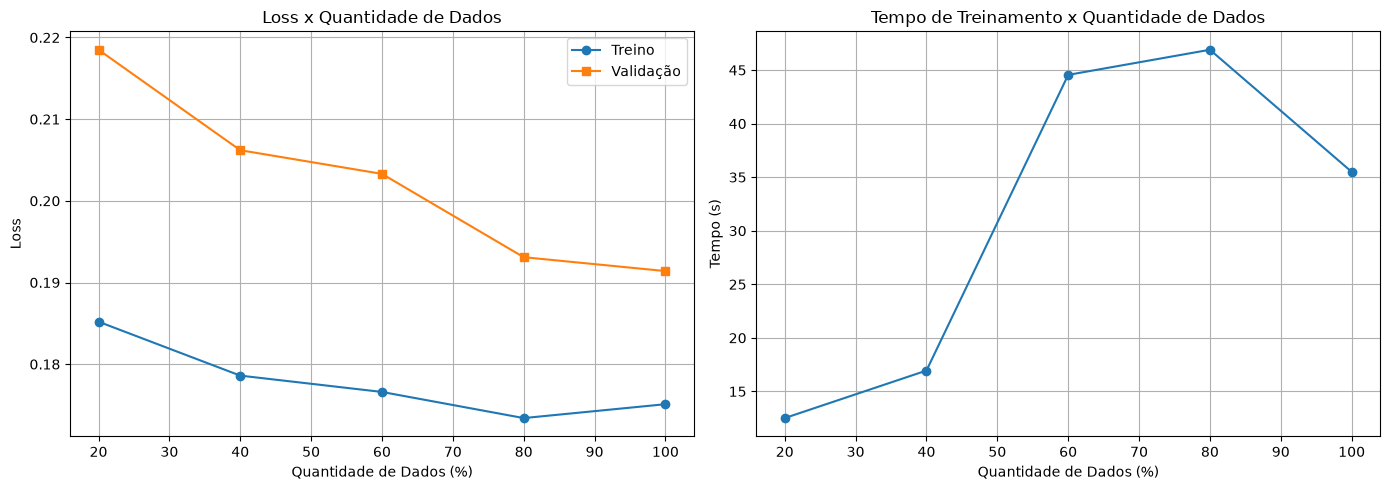

In [56]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14,5)
)

ax1.plot(
    df_q4["Dados (%)"],
    df_q4["Loss Treino"],
    marker='o',
    label='Treino'
)

ax1.plot(
    df_q4["Dados (%)"],
    df_q4["Loss Validação"],
    marker='s',
    label='Validação'
)

ax1.set_xlabel("Quantidade de Dados (%)")
ax1.set_ylabel("Loss")
ax1.set_title("Loss x Quantidade de Dados")
ax1.grid(True)
ax1.legend()

ax2.plot(
    df_q4["Dados (%)"],
    df_q4["Tempo (s)"],
    marker='o'
)

ax2.set_xlabel("Quantidade de Dados (%)")
ax2.set_ylabel("Tempo (s)")
ax2.set_title("Tempo de Treinamento x Quantidade de Dados")
ax2.grid(True)

plt.tight_layout()
plt.show()

## 5.Influência dos Atributos – Quantidade, Qualidade e Sensibilidade das Features

In [71]:
X_temp, X_val, y_temp, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)

scaler = StandardScaler()

X_temp = scaler.fit_transform(X_temp)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_temp = pd.DataFrame(X_temp, columns=x.columns)
X_val = pd.DataFrame(X_val, columns=x.columns)
X_test = pd.DataFrame(X_test, columns=x.columns)

In [72]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_temp, y_temp)

importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nRanking das Features:\n")
print(importance)


Ranking das Features:

            Feature  Importance
14     ShapeFactor3    0.089701
3   MinorAxisLength    0.088567
11      Compactness    0.083193
12     ShapeFactor1    0.079672
1         Perimeter    0.079626
2   MajorAxisLength    0.078404
6        ConvexArea    0.077560
5      Eccentricity    0.071450
7     EquivDiameter    0.066753
4      AspectRation    0.063744
0              Area    0.059772
10        roundness    0.056993
13     ShapeFactor2    0.040791
15     ShapeFactor4    0.033864
9          Solidity    0.019225
8            Extent    0.010685


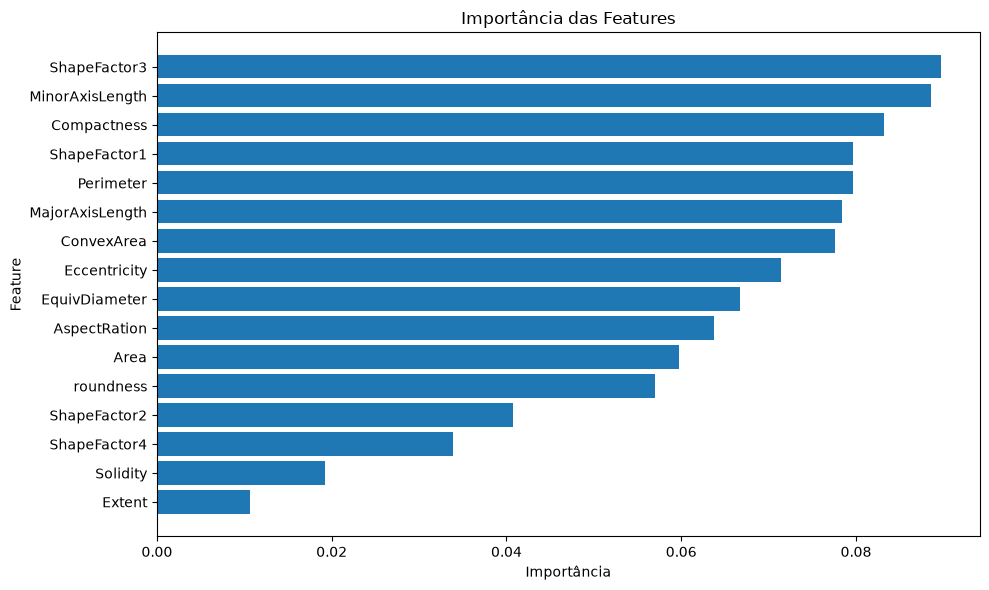

In [73]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importância")
plt.ylabel("Feature")
plt.title("Importância das Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [76]:
feature_sets = {
    "All Features": x.columns.tolist(),
    "Top 12": importance["Feature"].iloc[:12].tolist(),
    "Top 8": importance["Feature"].iloc[:8].tolist(),
    "Top 4": importance["Feature"].iloc[:4].tolist(),
    "Without Top 4": importance["Feature"].iloc[4:].tolist(),
    "Worst 4": importance["Feature"].iloc[-4:].tolist()
}

def create_model(input_dim):

    model = Sequential()

    model.add(Dense(
        64,
        activation='relu',
        input_shape=(input_dim,)
    ))

    model.add(Dense(
        32,
        activation='relu'
    ))

    model.add(Dense(
        7,
        activation='softmax'
    ))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [79]:
def evaluate_feature_set(features):

    Xtr = X_train[features]
    Xvl = X_val[features]

    model = create_model(len(features))

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    start = time.time()

    history = model.fit(
        Xtr,
        y_train,
        validation_data=(Xvl, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    training_time = time.time() - start

    loss, acc = model.evaluate(
        Xvl,
        y_val,
        verbose=0
    )

    y_pred = model.predict(
        Xvl,
        verbose=0
    )

    y_pred = np.argmax(
        y_pred,
        axis=1
    )

    f1 = f1_score(
        y_val,
        y_pred,
        average='weighted'
    )

    return {
        "history": history,
        "loss": loss,
        "accuracy": acc,
        "f1": f1,
        "time": training_time
    }

In [80]:
results = {}

for name, features in feature_sets.items():

    print(f"Executando: {name}")

    results[name] = evaluate_feature_set(features)

table = pd.DataFrame({
    "Features": results.keys(),
    "Qtd Features": [len(feature_sets[k]) for k in results.keys()],
    "Loss": [results[k]["loss"] for k in results.keys()],
    "Accuracy": [results[k]["accuracy"] for k in results.keys()],
    "F1-Score": [results[k]["f1"] for k in results.keys()],
    "Tempo (s)": [results[k]["time"] for k in results.keys()]
})

table = table.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nResultados:\n")
print(table)

Executando: All Features


c:\Users\beand\Documents\t2-ic\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Executando: Top 12


c:\Users\beand\Documents\t2-ic\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Executando: Top 8


...

Executando: Without Top 4


c:\Users\beand\Documents\t2-ic\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Executando: Worst 4


c:\Users\beand\Documents\t2-ic\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Resultados:

        Features  Qtd Features      Loss  Accuracy  F1-Score  Tempo (s)
4  Without Top 4            12  0.165915  0.941724  0.941774  20.992215
0   All Features            16  0.166142  0.938785  0.938801  20.487800
1         Top 12            12  0.208882  0.922625  0.922690  19.175175
2          Top 8             8  0.231337  0.913810  0.914228  20.213441
3          Top 4             4  0.293347  0.885406  0.885391  21.318901
5        Worst 4             4  0.579909  0.761019  0.761939  19.616134


In [81]:
best = table.iloc[0]

print("\nMelhor configuração:")
print(best)


Melhor configuração:
Features        Without Top 4
Qtd Features               12
Loss                 0.165915
Accuracy             0.941724
F1-Score             0.941774
Tempo (s)           20.992215
Name: 4, dtype: object


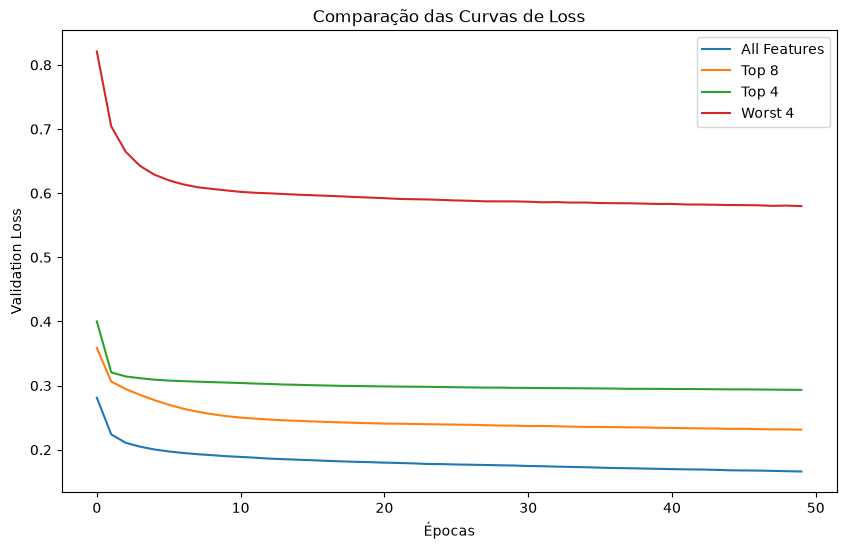

In [82]:
plt.figure(figsize=(10,6))

for name in [
    'All Features',
    'Top 8',
    'Top 4',
    'Worst 4'
]:

    plt.plot(
        results[name]['history'].history['val_loss'],
        label=name
    )

plt.xlabel("Épocas")
plt.ylabel("Validation Loss")

plt.legend()

plt.title(
    "Comparação das Curvas de Loss"
)

plt.show()

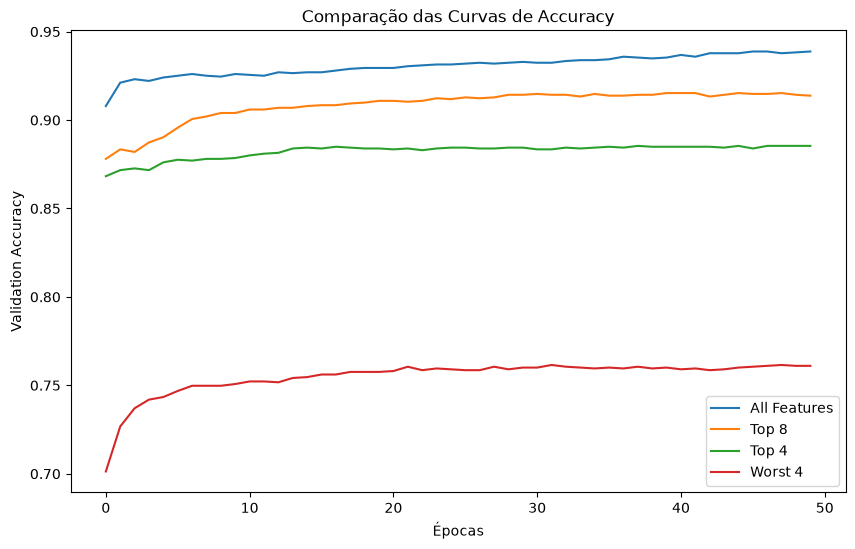

In [83]:
plt.figure(figsize=(10,6))

for name in [
    'All Features',
    'Top 8',
    'Top 4',
    'Worst 4'
]:

    plt.plot(
        results[name]['history'].history['val_accuracy'],
        label=name
    )

plt.xlabel("Épocas")
plt.ylabel("Validation Accuracy")

plt.legend()

plt.title(
    "Comparação das Curvas de Accuracy"
)

plt.show()

## Validação Inicial – Conjuntos de Treinamento e Teste

In [89]:
configs = [

    {
        "nome": "Rede 1",
        "hidden_layers": [40]          
    },

    {
        "nome": "Rede 2",
        "hidden_layers": [50]         
    },

    {
        "nome": "Rede 3",
        "hidden_layers": [10, 10]     
    },

    {
        "nome": "Rede 4",
        "hidden_layers": [60]          
    }
]
LEARNING_RATE = 0.01
MOMENTUM = 0.7


In [90]:
def criar_modelo(hidden_layers):

    model = Sequential()

    model.add(
        Input(shape=(X_train.shape[1],))
    )

    for neurons in hidden_layers:
        model.add(
            Dense(
                neurons,
                activation='relu'
            )
        )

    model.add(
        Dense(
            len(np.unique(y_train)),
            activation='softmax'
        )
    )

    optimizer = SGD(
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [88]:
print(y_train.shape)
print(y_train[:5])

(8166,)
[5 2 5 6 2]


In [91]:

resultados = []
historicos = {}

for cfg in configs:

    print("\n========================================")
    print(f"Treinando {cfg['nome']}")
    print(f"Topologia: {cfg['hidden_layers']}")
    print("========================================")

    model = criar_modelo(
        cfg["hidden_layers"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=50,
        batch_size=32,
        verbose=0
    )

    historicos[cfg["nome"]] = history

    train_loss, train_acc = model.evaluate(
        X_train,
        y_train,
        verbose=0
    )

    test_loss, test_acc = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    y_pred_prob = model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        y_pred_prob,
        axis=1
    )

    y_true = y_test

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    gap = abs(
        train_acc - test_acc
    )

    resultados.append({

        "Rede":
            cfg["nome"],

        "Topologia":
            str(cfg["hidden_layers"]),

        "Train Loss":
            train_loss,

        "Test Loss":
            test_loss,

        "Train Accuracy":
            train_acc,

        "Test Accuracy":
            test_acc,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1-Score":
            f1,

        "Gap":
            gap
    })

resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.round(4)

print("\n")
print("="*90)
print("RESULTADOS FINAIS")
print("="*90)

print(resultados_df)



Treinando Rede 1
Topologia: [40]

Treinando Rede 2
Topologia: [50]

Treinando Rede 3
Topologia: [10, 10]

Treinando Rede 4
Topologia: [60]


RESULTADOS FINAIS
     Rede Topologia  Train Loss  Test Loss  Train Accuracy  Test Accuracy  \
0  Rede 1      [40]      0.1879     0.2057          0.9308         0.9243   
1  Rede 2      [50]      0.1860     0.2044          0.9313         0.9243   
2  Rede 3  [10, 10]      0.1926     0.2081          0.9286         0.9174   
3  Rede 4      [60]      0.1851     0.2057          0.9324         0.9243   

   Precision  Recall  F1-Score     Gap  
0     0.9249  0.9243    0.9245  0.0065  
1     0.9251  0.9243    0.9245  0.0070  
2     0.9179  0.9174    0.9175  0.0112  
3     0.9253  0.9243    0.9246  0.0081  


In [92]:
melhor_rede = (
    resultados_df
    .sort_values(
        by=[
            "F1-Score",
            "Gap"
        ],
        ascending=[
            False,
            True
        ]
    )
    .iloc[0]
)

print("\n")
print("="*90)
print("MELHOR CONFIGURAÇÃO")
print("="*90)

print(melhor_rede)



MELHOR CONFIGURAÇÃO
Rede              Rede 4
Topologia           [60]
Train Loss        0.1851
Test Loss         0.2057
Train Accuracy    0.9324
Test Accuracy     0.9243
Precision         0.9253
Recall            0.9243
F1-Score          0.9246
Gap               0.0081
Name: 3, dtype: object


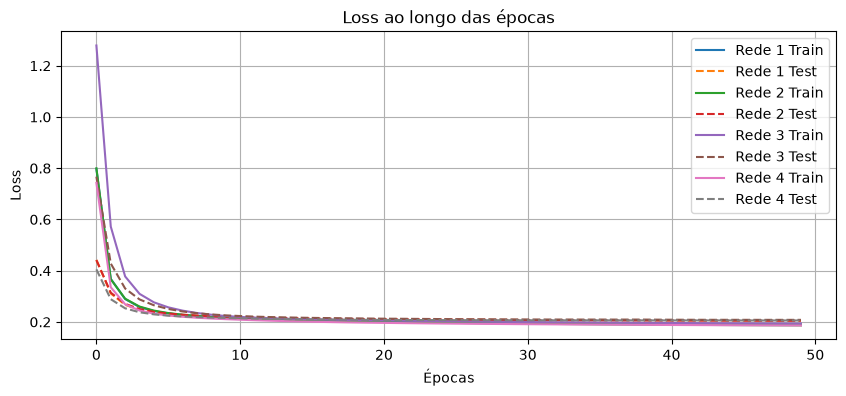

In [94]:
plt.figure(figsize=(10,4))

for nome, history in historicos.items():

    plt.plot(
        history.history["loss"],
        label=f"{nome} Train"
    )

    plt.plot(
        history.history["val_loss"],
        linestyle="--",
        label=f"{nome} Test"
    )

plt.title("Loss ao longo das épocas")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

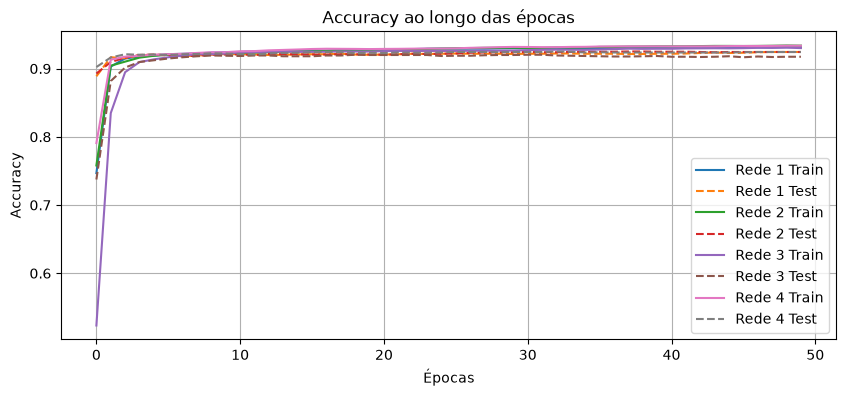

In [95]:
plt.figure(figsize=(10,4))

for nome, history in historicos.items():

    plt.plot(
        history.history["accuracy"],
        label=f"{nome} Train"
    )

    plt.plot(
        history.history["val_accuracy"],
        linestyle="--",
        label=f"{nome} Test"
    )

plt.title("Accuracy ao longo das épocas")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()


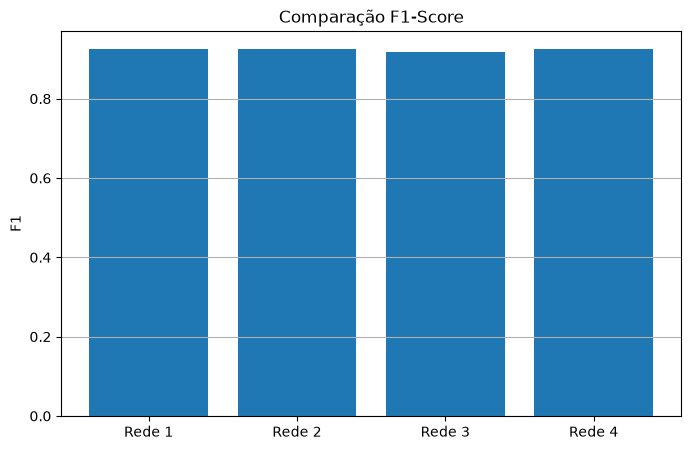

In [96]:
plt.figure(figsize=(8,5))

plt.bar(
    resultados_df["Rede"],
    resultados_df["F1-Score"]
)

plt.title("Comparação F1-Score")
plt.ylabel("F1")
plt.grid(axis='y')

plt.show()

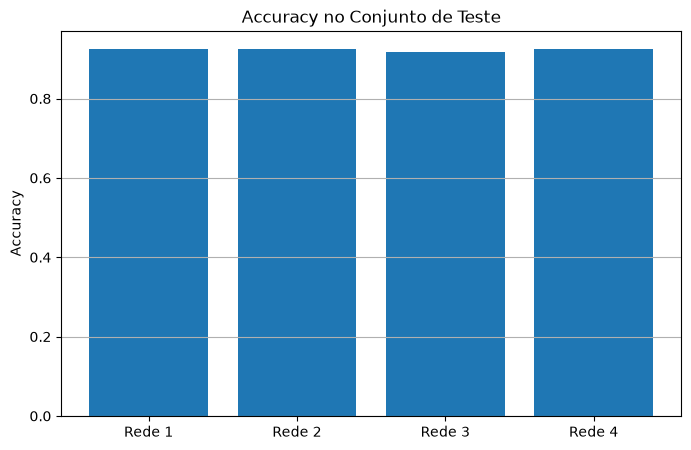

In [97]:
plt.figure(figsize=(8,5))

plt.bar(
    resultados_df["Rede"],
    resultados_df["Test Accuracy"]
)

plt.title("Accuracy no Conjunto de Teste")
plt.ylabel("Accuracy")

plt.grid(axis='y')

plt.show()

## 7.Validação Cruzada e Comparativa de Configurações Finais – Avaliação Consolidada

In [99]:
N_HIDDEN = 40
LEARNING_RATE = 0.01
MOMENTUM = 0.7

K = 5

def criar_modelo():

    model = Sequential([

        Input(shape=(x.shape[1],)),

        Dense(
            N_HIDDEN,
            activation='relu'
        ),

        Dense(
            len(np.unique(y)),
            activation='softmax'
        )
    ])

    optimizer = SGD(
        learning_rate=LEARNING_RATE,
        momentum=MOMENTUM
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

skf = StratifiedKFold(
    n_splits=K,
    shuffle=True,
    random_state=42
)


In [102]:
fold_results = []

histories = []

for fold, (train_idx, test_idx) in enumerate(
    skf.split(x, y),
    start=1
):

    print("\n===================================")
    print(f"Fold {fold}/{K}")
    print("===================================")


    X_train_fold = x.iloc[train_idx].values
    X_test_fold = x.iloc[test_idx].values

    y_train_fold = y[train_idx]
    y_test_fold = y[test_idx]

    model = criar_modelo()

    history = model.fit(
        X_train_fold,
        y_train_fold,
        validation_data=(
            X_test_fold,
            y_test_fold
        ),
        epochs=50,
        batch_size=32,
        verbose=0
    )

    histories.append(history)

    loss, accuracy = model.evaluate(
        X_test_fold,
        y_test_fold,
        verbose=0
    )

    y_prob = model.predict(
        X_test_fold,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    precision = precision_score(
        y_test_fold,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test_fold,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test_fold,
        y_pred,
        average='weighted'
    )

    fold_results.append({

        "Fold": fold,

        "Loss": loss,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1-Score": f1

    })

df_folds = pd.DataFrame(fold_results)

df_folds = df_folds.round(4)

print("\n")
print("="*80)
print("RESULTADOS POR FOLD")
print("="*80)

print(df_folds)


Fold 1/5


c:\Users\beand\Documents\t2-ic\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Fold 2/5


c:\Users\beand\Documents\t2-ic\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Fold 3/5


c:\Users\beand\Documents\t2-ic\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Fold 4/5


c:\Users\beand\Documents\t2-ic\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Fold 5/5


RESULTADOS POR FOLD
   Fold    Loss  Accuracy  Precision  Recall  F1-Score
0     1  1.8347    0.2607     0.0680  0.2607    0.1079
1     2  1.8344    0.2605     0.0678  0.2605    0.1076
2     3  1.8345    0.2605     0.0678  0.2605    0.1076
3     4  1.8345    0.2605     0.0678  0.2605    0.1076
4     5  1.8348    0.2605     0.0678  0.2605    0.1076


c:\Users\beand\Documents\t2-ic\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [103]:
df_folds = pd.DataFrame(
    fold_results
)

df_folds = df_folds.round(4)

print("\n")
print("="*80)
print("RESULTADOS POR FOLD")
print("="*80)

print(df_folds)

medias = df_folds.mean(
    numeric_only=True
)

desvios = df_folds.std(
    numeric_only=True
)

variancias = df_folds.var(
    numeric_only=True
)

resumo = pd.DataFrame({

    "Média": medias,
    "Desvio Padrão": desvios,
    "Variância": variancias

})

resumo = resumo.round(6)

print("\n")
print("="*80)
print("ESTATÍSTICAS FINAIS")
print("="*80)

print(resumo)




RESULTADOS POR FOLD
   Fold    Loss  Accuracy  Precision  Recall  F1-Score
0     1  1.8347    0.2607     0.0680  0.2607    0.1079
1     2  1.8344    0.2605     0.0678  0.2605    0.1076
2     3  1.8345    0.2605     0.0678  0.2605    0.1076
3     4  1.8345    0.2605     0.0678  0.2605    0.1076
4     5  1.8348    0.2605     0.0678  0.2605    0.1076


ESTATÍSTICAS FINAIS
             Média  Desvio Padrão  Variância
Fold       3.00000       1.581139        2.5
Loss       1.83458       0.000164        0.0
Accuracy   0.26054       0.000089        0.0
Precision  0.06784       0.000089        0.0
Recall     0.26054       0.000089        0.0
F1-Score   0.10766       0.000134        0.0


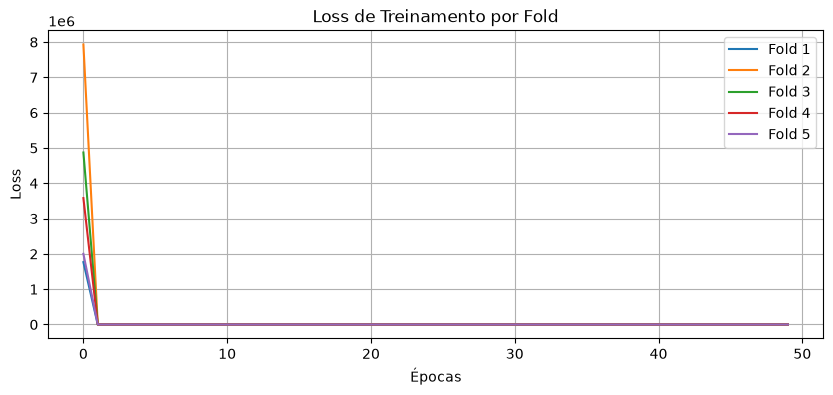

In [105]:
plt.figure(figsize=(10,4))

for i, history in enumerate(histories):

    plt.plot(
        history.history["loss"],
        label=f"Fold {i+1}"
    )

plt.title(
    "Loss de Treinamento por Fold"
)

plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.grid(True)
plt.legend()

plt.show()

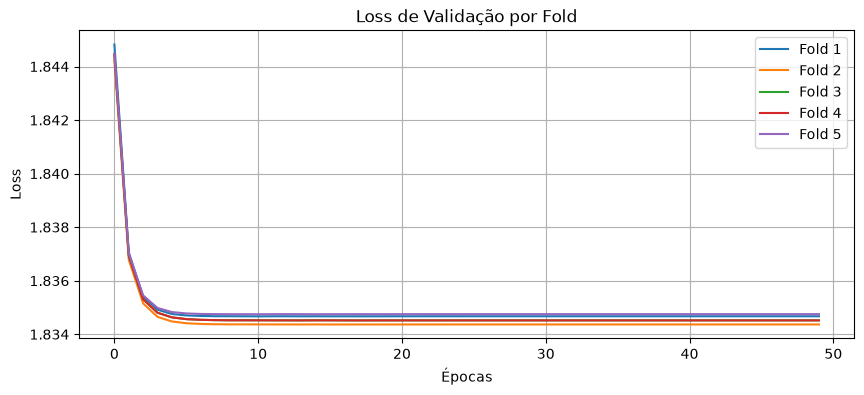

In [107]:
plt.figure(figsize=(10,4))

for i, history in enumerate(histories):

    plt.plot(
        history.history["val_loss"],
        label=f"Fold {i+1}"
    )

plt.title(
    "Loss de Validação por Fold"
)

plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.grid(True)
plt.legend()

plt.show()

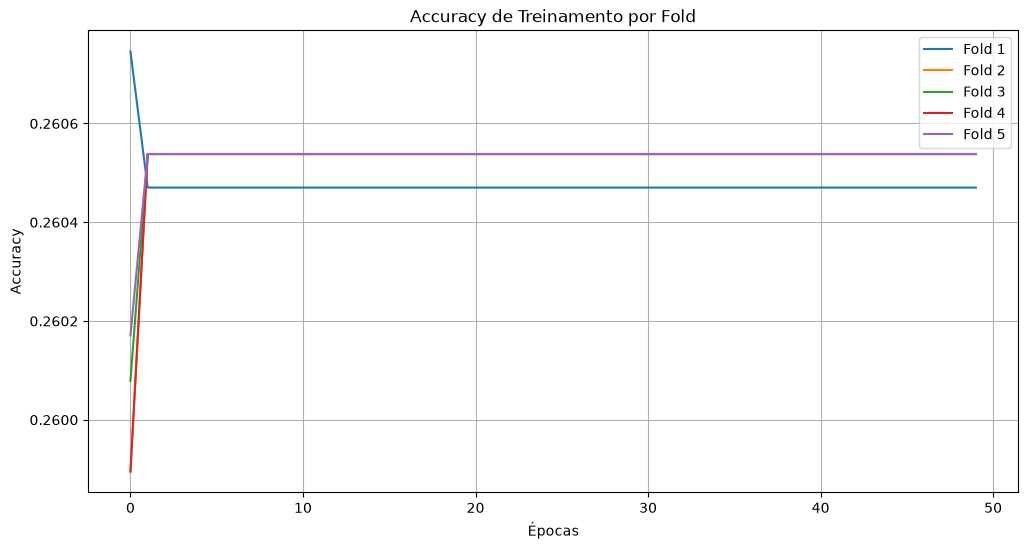

In [108]:
plt.figure(figsize=(12,6))

for i, history in enumerate(histories):

    plt.plot(
        history.history["accuracy"],
        label=f"Fold {i+1}"
    )

plt.title(
    "Accuracy de Treinamento por Fold"
)

plt.xlabel("Épocas")
plt.ylabel("Accuracy")

plt.grid(True)
plt.legend()

plt.show()

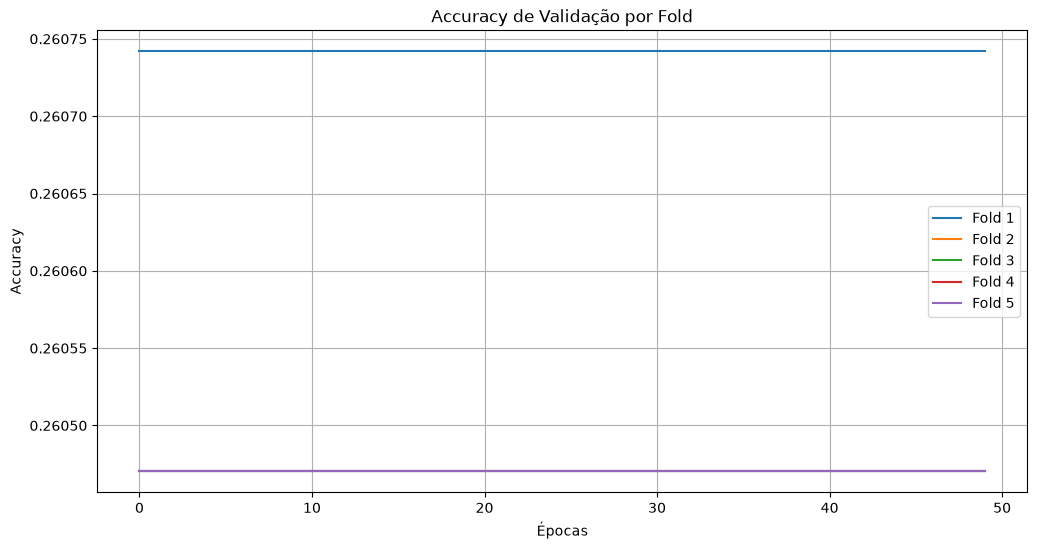

In [109]:
plt.figure(figsize=(12,6))

for i, history in enumerate(histories):

    plt.plot(
        history.history["val_accuracy"],
        label=f"Fold {i+1}"
    )

plt.title(
    "Accuracy de Validação por Fold"
)

plt.xlabel("Épocas")
plt.ylabel("Accuracy")

plt.grid(True)
plt.legend()

plt.show()

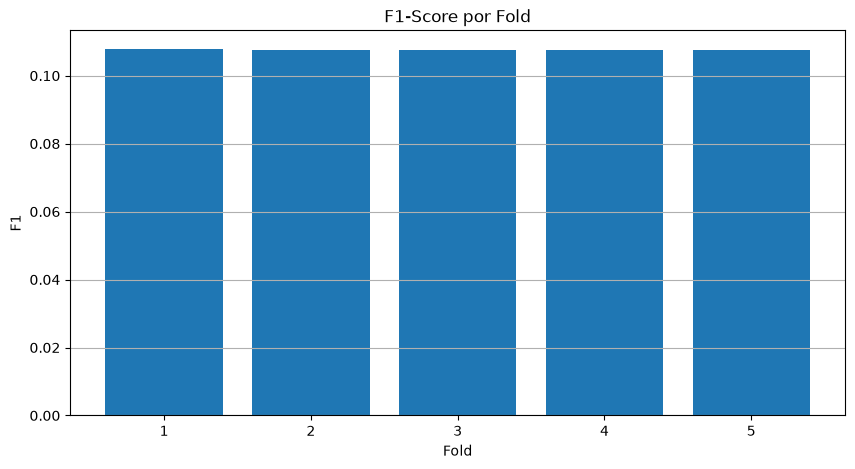

In [110]:
plt.figure(figsize=(10,5))

plt.bar(
    df_folds["Fold"],
    df_folds["F1-Score"]
)

plt.title(
    "F1-Score por Fold"
)

plt.xlabel("Fold")
plt.ylabel("F1")

plt.grid(axis='y')

plt.show()

In [111]:
df_folds.to_csv(
    "resultado_kfold_folds.csv",
    index=False
)

resumo.to_csv(
    "resultado_kfold_resumo.csv"
)

print("\nArquivos gerados:")
print("resultado_kfold_folds.csv")
print("resultado_kfold_resumo.csv")

print("\n")
print("="*80)
print("DESEMPENHO FINAL DA REDE")
print("="*80)

print(f"Accuracy Média : {medias['Accuracy']:.4f}")
print(f"F1 Médio       : {medias['F1-Score']:.4f}")
print(f"Loss Médio     : {medias['Loss']:.4f}")

print(f"\nAccuracy Std   : {desvios['Accuracy']:.4f}")
print(f"F1 Std         : {desvios['F1-Score']:.4f}")
print(f"Loss Std       : {desvios['Loss']:.4f}")


Arquivos gerados:
resultado_kfold_folds.csv
resultado_kfold_resumo.csv


DESEMPENHO FINAL DA REDE
Accuracy Média : 0.2605
F1 Médio       : 0.1077
Loss Médio     : 1.8346

Accuracy Std   : 0.0001
F1 Std         : 0.0001
Loss Std       : 0.0002
